Essa rede neural será treinada para aprender a função XNOR,
diferentemente do perceptron de uma camada, esta rede neural terá multiplos neuronios, e uma camada oculta, 

Sua estrutura será:

[Camada entrada com 2 neuronios + bias]

                   |
                   |
                   v 

[Camada oculta com 2 neuronios + bias] 

                   |
                   |
                   v
                   
[Camada saída com um neuronio (Saída da rede neural)] 


In [1]:
import numpy as np
import tensorflow as tf

Inicia-se as entradas e saídas da função XNOR

In [2]:
X = np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])

X

array([[0., 0.],
       [0., 1.],
       [1., 0.],
       [1., 1.]])

In [3]:
Y = np.array([[1.0], [0.0], [0.0], [1.0]])

Y

array([[1.],
       [0.],
       [0.],
       [1.]])

Define-se a estrutura da rede neural e seus pesos.
Serão 6 pesos na camada de entrada, e 3 pesos na camada oculta

Todos inicializados aleatóriamente seguindo uma distribuição normal (Acredito que Z)

In [4]:
num_neuronios_entrada = 2
num_neuronios_ocultos = 3
num_neuronios_saida = 1

W = {"entrada": tf.Variable(tf.random.normal([num_neuronios_entrada, num_neuronios_ocultos], dtype=tf.float64), name="w_entrada"),
     "oculta": tf.Variable(tf.random.normal([num_neuronios_ocultos, num_neuronios_saida], dtype=tf.float64), name="w_oculta")}

W

{'entrada': <tf.Variable 'w_entrada:0' shape=(2, 3) dtype=float64, numpy=
 array([[-1.38417658, -0.53316551,  0.24799786],
        [-0.95063973,  0.5452094 ,  1.28295092]])>,
 'oculta': <tf.Variable 'w_oculta:0' shape=(3, 1) dtype=float64, numpy=
 array([[-1.04556463],
        [-0.33532874],
        [-0.12946861]])>}

C:\Users\Mileguir\AppData\Local\Temp\ipykernel_46084\3312776576.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(W["entrada"])


<Axes: xlabel='w_entrada:0', ylabel='Density'>

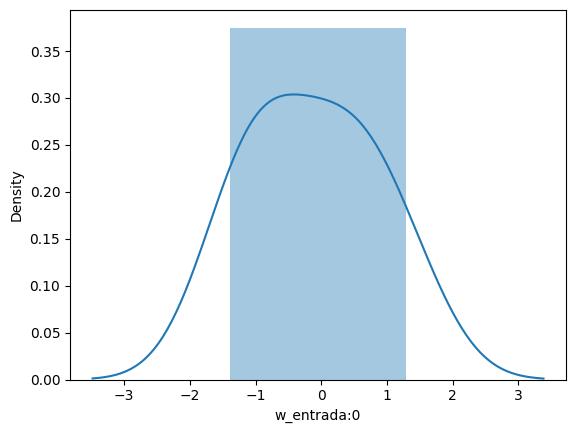

In [5]:
import seaborn as sns

sns.distplot(W["entrada"])

C:\Users\Mileguir\AppData\Local\Temp\ipykernel_46084\146825927.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(W["oculta"])


<Axes: xlabel='w_oculta:0', ylabel='Density'>

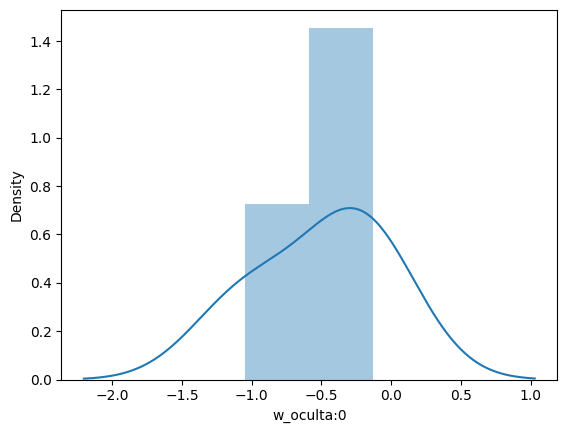

In [6]:
sns.distplot(W["oculta"])

Agora serão adicionados as biases de cada camada da rede neural, representadas como um neuronio com conexões com cada neuronio da próxima camada:

In [7]:
b = {"entrada": tf.Variable(tf.random.normal([num_neuronios_ocultos], dtype=tf.float64), name="bias_entrada"),
     "oculta": tf.Variable(tf.random.normal([num_neuronios_saida], dtype=tf.float64), name="bias_oculta")}

b

{'entrada': <tf.Variable 'bias_entrada:0' shape=(3,) dtype=float64, numpy=array([-0.66266823,  1.43567326,  1.36125667])>,
 'oculta': <tf.Variable 'bias_oculta:0' shape=(1,) dtype=float64, numpy=array([-1.98381363])>}

A seguir será realizado o treinamento da rede neural utilizando métodos de diferenciação automatica para a função erro aplicada com os pesos e as biases.

Em seguida, os valores dos gradientes encontrados automaticamente por esse método, serão aplicados ao otimizador, que fará automaticamente o ajuste dos pesos "por baixo dos panos":

In [8]:
otimizador = tf.keras.optimizers.SGD(learning_rate = 0.3)

for epoch in range(10000):
    with tf.GradientTape() as tape:
            
        #Faz a soma dos pesos * entradas + bias
        soma_camada_oculta = tf.add(tf.matmul(X, W["entrada"]), b["entrada"])

        #Faz a ativacao da soma para passar como entrada para cada neuronio da camada oculta
        ativacao_camada_oculta = tf.sigmoid(soma_camada_oculta)

        #Repete o processo para camada de saida
        soma_camada_saida = tf.add(tf.matmul(ativacao_camada_oculta, W["oculta"]), b["oculta"])
        ativacao_camada_saida = tf.sigmoid(soma_camada_saida)

        #Define a funcao custo
        error = tf.losses.MSE(Y, ativacao_camada_saida)

        #Faz a diferenciacao da funcao custo em relação aos pesos e biases, e calcula o gradiente automaticamente
        var_list = [W['entrada'], W['oculta'], b['entrada'], b['oculta']]

        gradiente = tape.gradient(error, var_list)

        #Aplica o gradiente para o otimizador para fazer o ajuste dos pesos e biases automaticamente
        otimizador.apply_gradients(zip(gradiente, var_list))

        if epoch % 200 == 0:
            
            #Calcula o erro médio a cada 200 epochs
            erro_medio = tf.reduce_mean(error).numpy()
            print(erro_medio)

0.4338078014036718
0.24293604140908842
0.21077518888893343
0.15938833464024707
0.13443975917522852
0.025772648719558276
0.010056099464309293
0.0058417375476859
0.004024312027445765
0.003037934254542015
0.0024262350765976797
0.0020126471783719346
0.0017156079069125326
0.0014925749238458024
0.0013193060598493565
0.0011810251455192258
0.001068235867682019
0.0009745685386614521
0.0008955974041767701
0.0008281551625630651
0.0007699174413019229
0.0007191411596483024
0.0006744943240539546
0.0006349421241759998
0.0005996687915015163
0.0005680228041244588
0.0005394777056295839
0.0005136035948812523
0.000490046051288304
0.000468510332626747
0.0004487493715597953
0.0004305545489180955
0.000413748523816122
0.00039817960600551527
0.0003837172976734564
0.0003702487312651977
0.00035767580048399404
0.00034591283237143055
0.0003348846852894128
0.0003245251847726614
0.0003147758293851214
0.00030558471383372934
0.00029690562803069774
0.00028869729952051324
0.000280922753395431
0.00027354876901855503
0.00

In [9]:
#Amostra dos pesos e biases já treinados:

print(W)
print(b)

{'entrada': <tf.Variable 'w_entrada:0' shape=(2, 3) dtype=float64, numpy=
array([[-4.656816  , -5.51474584, -6.3586458 ],
       [-5.40741098,  7.13812268,  3.39569172]])>, 'oculta': <tf.Variable 'w_oculta:0' shape=(3, 1) dtype=float64, numpy=
array([[ 5.64247103],
       [ 8.81317142],
       [-9.17659072]])>}
{'entrada': <tf.Variable 'bias_entrada:0' shape=(3,) dtype=float64, numpy=array([ 1.03755033,  2.33584483, -0.84621163])>, 'oculta': <tf.Variable 'bias_oculta:0' shape=(1,) dtype=float64, numpy=array([-4.54011222])>}


Agora farei o teste da rede neural já treinada em cima da função XNOR:

In [10]:
# teste
camada_oculta_teste = tf.add(tf.matmul(X, W['entrada']), b['entrada'])
camada_oculta_ativacao_teste = tf.sigmoid(camada_oculta_teste)
camada_saida_teste = tf.add(tf.matmul(camada_oculta_ativacao_teste, W['oculta']), b['oculta'])
camada_saida_ativacao_teste = tf.sigmoid(camada_saida_teste)

print(camada_saida_ativacao_teste)
print(Y)

tf.Tensor(
[[0.99265935]
 [0.01523575]
 [0.01716783]
 [0.9803483 ]], shape=(4, 1), dtype=float64)
[[1.]
 [0.]
 [0.]
 [1.]]


Pode notar-se que o resultado está aproximadamente correto

A seguir segue o gráfico com os pontos da função XNOR, e a curva que a rede neural aprendeu para separar as classes Y = 0 e Y = 1 no plano:

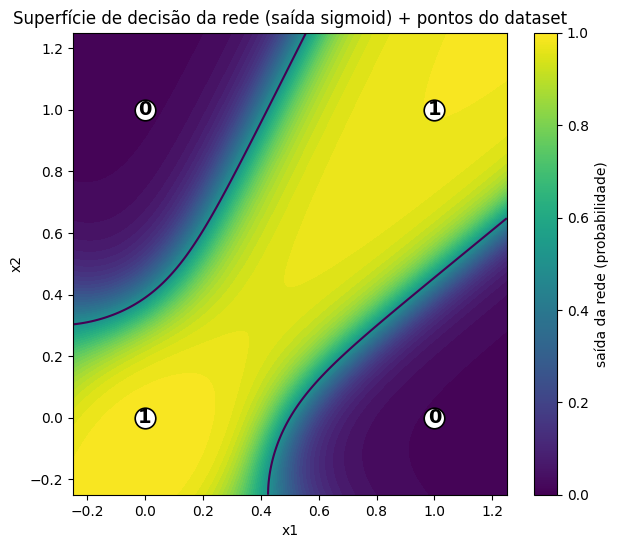

In [15]:
import matplotlib.pyplot as plt

# Seus 4 pontos (inputs)
X = np.array([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.],
], dtype=np.float64)

# Seus rótulos (isso aqui é XNOR como você descreveu)
y = np.array([1., 0., 0., 1.], dtype=np.float64)

# Forward da sua rede (usa seus W e b já treinados)
@tf.function
def forward(X_tf):
    h = tf.add(tf.matmul(X_tf, W['entrada']), b['entrada'])
    h = tf.sigmoid(h)
    o = tf.add(tf.matmul(h, W['oculta']), b['oculta'])
    o = tf.sigmoid(o)
    return o  # shape (N, 1) ou (N,) dependendo de como estão seus pesos

# 1) Cria um grid no plano (um pouco além de 0..1 pra ficar bonito)
grid_n = 300
x1 = np.linspace(-0.25, 1.25, grid_n)
x2 = np.linspace(-0.25, 1.25, grid_n)
xx1, xx2 = np.meshgrid(x1, x2)

grid_points = np.stack([xx1.ravel(), xx2.ravel()], axis=1).astype(np.float64)

# 2) Avalia a rede no grid
pred = forward(tf.constant(grid_points, dtype=tf.float64))
pred = tf.reshape(pred, (-1,))          # garante 1D
Z = pred.numpy().reshape(xx1.shape)     # volta pro shape do grid

# 3) Plot: mapa da saída + contorno 0.5 + pontos do dataset
plt.figure(figsize=(7, 6))

# Mapa contínuo da probabilidade (0..1)
plt.contourf(xx1, xx2, Z, levels=50)

# Linha de decisão (threshold 0.5)
plt.contour(xx1, xx2, Z, levels=[0.5])

# (depois do contour/contourf)

# um marcador discretinho por trás (opcional)
plt.scatter(X[:, 0], X[:, 1], s=220, c="white", edgecolors="black", linewidths=1.2, zorder=5)

# o número em cima
for (x, y_), label in zip(X, y.astype(int)):
    plt.text(
        x, y_,
        str(label),
        ha="center", va="center",
        fontsize=14, fontweight="bold",
        zorder=6
    )


# Pontos do dataset
# (sem escolher cor manual: o matplotlib usa o cmap padrão)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

plt.xlim(x1.min(), x1.max())
plt.ylim(x2.min(), x2.max())
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Superfície de decisão da rede (saída sigmoid) + pontos do dataset")
plt.colorbar(label="saída da rede (probabilidade)")
plt.show()
